# Tasca S11 – Visualización de datos con Python y Power BI

Esta sesión práctica combina el uso de Python con las bibliotecas Pandas, Matplotlib, Seaborn y Plotly, así como su integración con Power BI. Se trabajará en todo el proceso, desde la conexión a MySQL hasta la creación de visualizaciones avanzadas en Python y, finalmente, la incorporación de estas visualizaciones en un informe dinámico de Power BI.

## NIVEL 1: Carga de datos y exploración de columnas

### 1.1: Conectamos Python a MySQL Workbench y cargamos los datos de la base de datos 'eshop' para utilizarlos en todos los ejercicios

In [20]:
# Instalamos el módulo conector de MySQL

!python -m pip install mysql-connector-python


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
# Instalamos la librería python-dotenv que nos permite leer las variables de entorno desde el archivo .env
!python -m pip install python-dotenv


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
# Importamos las librerías necesarias para poder leer las variables de entorno desde el archivo .env y comunicar con la base de datos MySQL

import mysql.connector
from mysql.connector import Error
from dotenv import load_dotenv
import os
import pandas as pd

'''
Cargamos las variables de entorno desde el archivo .env
Las variables de entorno nos permiten guardar datos sensibles como contraseñas 
fuera del código, en un archivo .env que nunca se publica en GitHub
'''
load_dotenv(dotenv_path=r"c:\Users\giorg\Desktop\IT Academy\Sprint 11\.env")

# Intentamos conectar con la base de datos MySQL
try:
    connection = mysql.connector.connect(
        host=os.getenv("DB_HOST"),
        database=os.getenv("DB_NAME"),
        user=os.getenv("DB_USER"),
        password=os.getenv("DB_PASSWORD")
    )
    # Verificamos que la conexión se ha establecido correctamente
    if connection.is_connected():
        db_Info = connection.server_info
        print("Connected to MySQL Server version ", db_Info)
        cursor = connection.cursor()
        cursor.execute("select database();")
        record = cursor.fetchone()
        print("You're connected to database: ", record)

# Capturamos cualquier error de conexión
except Error as e:
    print("Error while connecting to MySQL", e)

# Cerramos la conexión tanto si ha habido error como si no
finally:
    if 'connection' in dir() and connection.is_connected():
        cursor.close()
        connection.close()
        print("MySQL connection is closed")

Connected to MySQL Server version  8.4.3
You're connected to database:  ('eshop',)
MySQL connection is closed


Cargamos cada tabla de la base de datos 'eshop' como un DataFrame de Pandas.
Guardamos cada DataFrame en una **variable global** para poder reutilizarlo en todas las celdas del notebook sin necesidad de volver a conectarnos.
Finalmente, usamos un **bucle for** para recorrer todas las tablas y mostrar sus columnas de forma ordenada.

In [23]:
# Reconectamos para cargar las tablas
conexion = mysql.connector.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

# Cargamos todas las tablas como variables globales
df_actividad_tarjeta  = pd.read_sql("SELECT * FROM card_activity", conexion)
df_empresas           = pd.read_sql("SELECT * FROM companies", conexion)
df_tarjetas           = pd.read_sql("SELECT * FROM credit_cards", conexion)
df_productos          = pd.read_sql("SELECT * FROM products", conexion)
df_productos_vendidos = pd.read_sql("SELECT * FROM sold_products", conexion)
df_transacciones      = pd.read_sql("SELECT * FROM transactions", conexion)
df_usuarios           = pd.read_sql("SELECT * FROM users", conexion)

conexion.close()

# Mostramos las columnas de cada tabla con un bucle for
tablas = {
    "card_activity"  : df_actividad_tarjeta,
    "companies"      : df_empresas,
    "credit_cards"   : df_tarjetas,
    "products"       : df_productos,
    "sold_products"  : df_productos_vendidos,
    "transactions"   : df_transacciones,
    "users"          : df_usuarios
}

for nombre_tabla, df in tablas.items():
    print(f"\nTabla: {nombre_tabla}")
    for columna in df.columns:
        print(f"   - {columna}")


Tabla: card_activity
   - card_id
   - declined

Tabla: companies
   - company_id
   - company_name
   - phone
   - email
   - country
   - website

Tabla: credit_cards
   - id
   - user_id
   - iban
   - pan
   - pin
   - cvv
   - track1
   - track2
   - expiring_date

Tabla: products
   - id
   - product_name
   - price
   - colour
   - weight
   - warehouse_id

Tabla: sold_products
   - transaction_id
   - product_id

Tabla: transactions
   - id
   - card_id
   - business_id
   - timestamp
   - amount
   - declined
   - product_ids
   - user_id
   - lat
   - longitude

Tabla: users
   - id
   - name
   - surname
   - phone
   - email
   - birth_date
   - country
   - city
   - postal_code
   - address


### 1.2 Visualización de datos

In [24]:
# Importamos las librerías necesarias
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import warnings 

In [25]:
warnings.filterwarnings ("ignore") #ocultamos los mensajes de avisos que genera seaborn
sns.set() #fijamos el estilo gráfico de seaborn

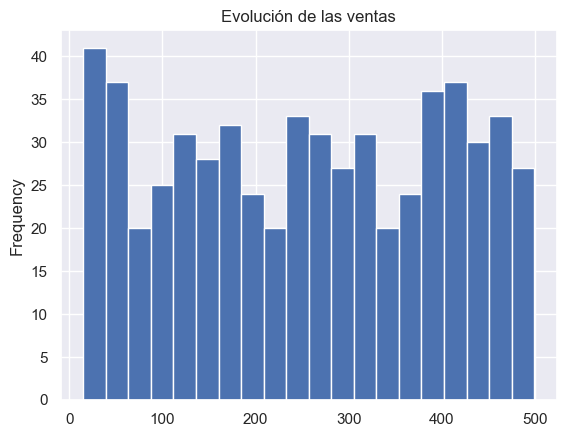

In [26]:
# Rapresentamos graficamente una variable numerica usando Pandas:

df_transacciones['amount'].plot.hist(bins=20).set_title('Evolución de las ventas');

El histograma muestra cómo se distribuyen los montos de las transacciones. Se observa que la mayoría de las transacciones tienen importes variados sin una concentración clara.

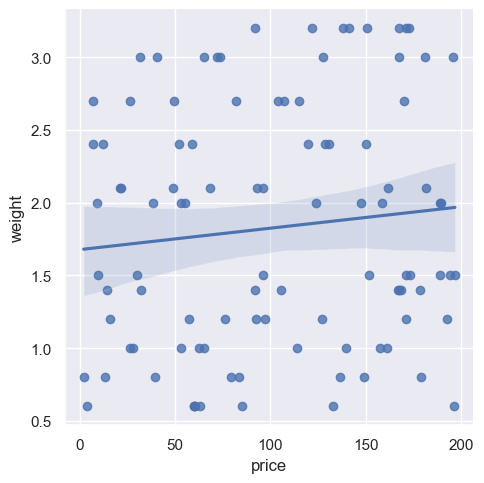

In [30]:
# Rapresentamos graficamente dos variables numericas usando Seaborn:

sns.lmplot(x='price', y='weight', data=df_productos);

El gráfico muestra que no existe correlación entre el precio y el peso de los productos, lo que sugiere que el precio se determina por otros factores como la marca o la categoría del producto.

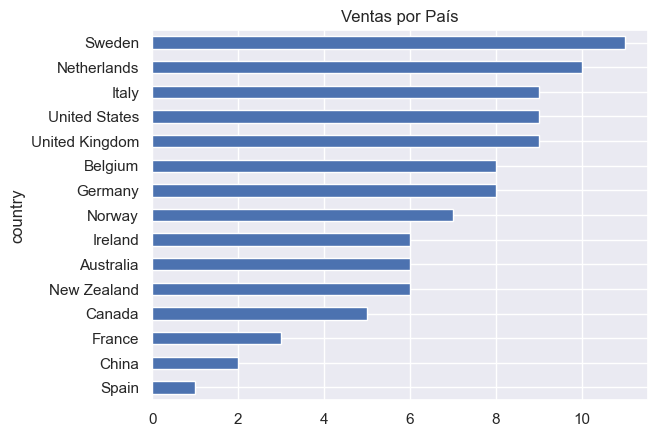

In [ ]:
# Rapresentamos graficamente una variable categorica usando Pandas:

df_empresas['country'].value_counts().sort_values().plot.barh().set_title('Ventas por País');


El gráfico muestra la distribución de empresas por país. Sweden y Netherlands son los países con más empresas, mientras que Spain y China tienen menos presencia.

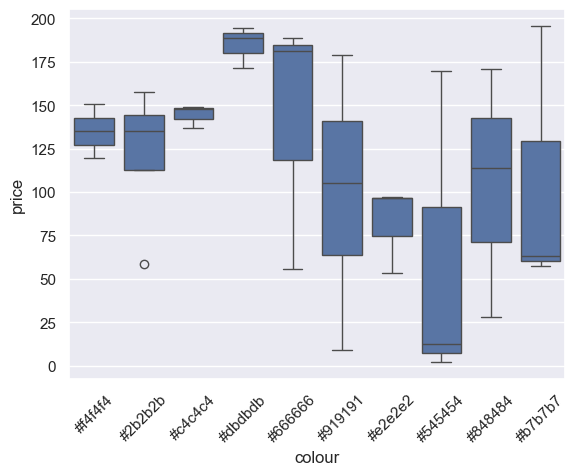

In [ ]:
# Rapresentamos graficamente una variable categorica y una numérica usando Seaborn.
# Mostramos solo los 10 colores más frecuentes y la relación con el precio através de un boxplot usando Seaborn:

top_colores = df_productos['colour'].value_counts().head(10).index
df_top = df_productos[df_productos['colour'].isin(top_colores)]

sns.boxplot(x='colour', y='price', data=df_top)
plt.xticks(rotation=45);


El boxplot muestra la distribución de precios para los 10 colores más frecuentes. Todos los colores son códigos hexadecimales de tonos grises, lo que sugiere que los datos han sido generados artificialmente. A pesar de esto, podemos observar que el color #dbdbdb tiene los precios más altos y #e2e2e2 la distribución más amplia.
El círculo en #2b2b2b representa un valor atípico (outlier).

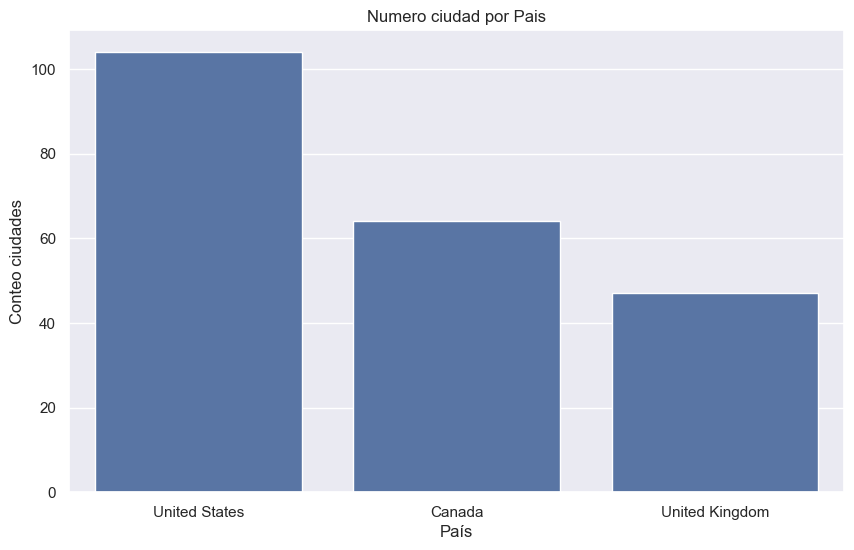

In [ ]:
#Rapresentamos graficamente dos variables categoricas con Seaborn
#Visualizamos cuantas ciudades están en cada país de usuarios

# 1. Ragrupamos por país y contamos la ciudades univocas
ciudad_por_pais = df_usuarios.groupby('country')['city'].nunique().sort_values(ascending=False).reset_index()

# 2. Creamos el grafico
plt.figure(figsize=(10, 6))
sns.barplot(data=ciudad_por_pais, x='country', y='city')

plt.title('Numero ciudad por Pais')
plt.xlabel('País')
plt.ylabel('Conteo ciudades');


El gráfico muestra el número de ciudades únicas por país. United States tiene el mayor número de ciudades activas, seguido de Canada y United Kingdom.
Esto refleja que la mayoría de los usuarios del eshop se concentran en Estados Unidos.

In [ ]:
!python -m pip install nbformat --upgrade


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Rapresentamos graficamente tres variables combinadas.
# Extraemos el año del campo timestamp
df_transacciones['year'] = pd.to_datetime(df_transacciones['timestamp']).dt.year

# Tres variables combinadas con Plotly
fig = px.box(df_transacciones, 
             x='year', 
             y='amount', 
             color='declined',
             title='Distribución del monto por año y estado de la transacción',
             labels={'year': 'Año', 'amount': 'Monto', 'declined': 'Rechazada'})

fig.show()

El gráfico combina tres variables: el año de la transacción, el monto y si fue rechazada (1) o aceptada (0).
En 2021 las transacciones aceptadas tienen montos más altos que las rechazadas.
En 2022 la tendencia se invierte: las transacciones rechazadas presentan montos más elevados.

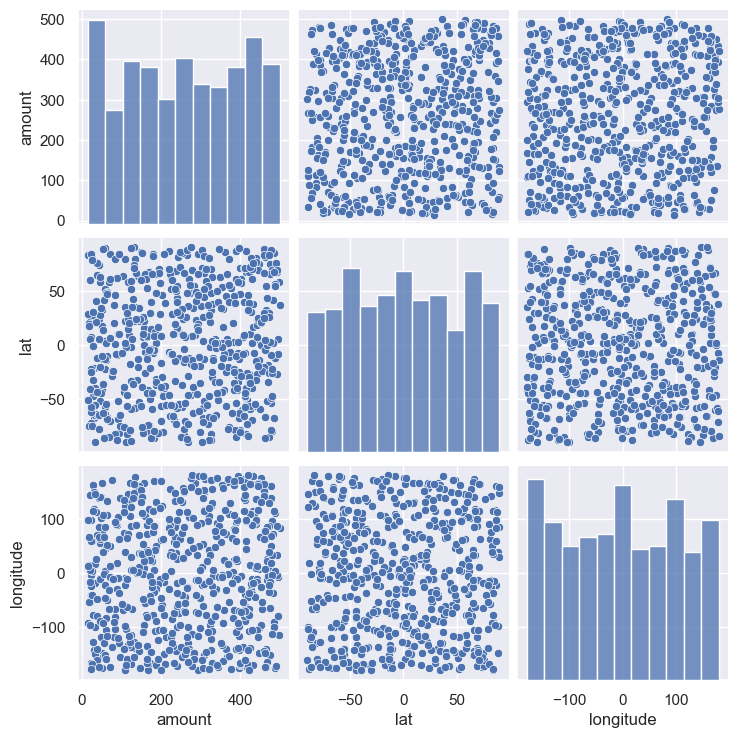

In [37]:
# El pairplot muestra la relación entre todas las variables numéricas a la vez

sns.pairplot(df_transacciones[['amount', 'lat', 'longitude']]);

El pairplot muestra la relación entre amount, lat y longitude. En la diagonal se puede ver la distribución individual de cada variable.
Los scatter plots muestran puntos dispersos sin ningún patrón claro, lo que confirma que el importe de las transacciones no depende de la ubicación geográfica.

## NIVEL 2: Análisis de correlaciones y relaciones entre variables

### 2.1: Interpretación de correlaciones entre variables


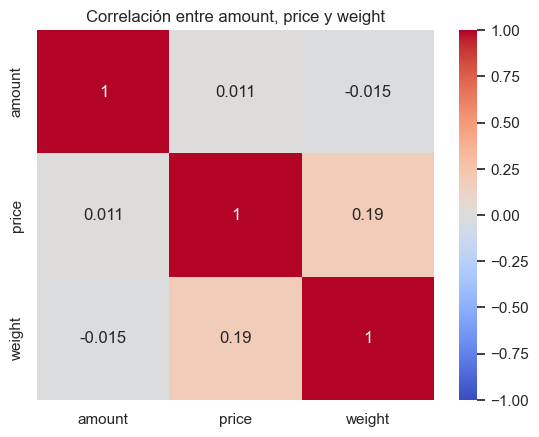

In [ ]:
# Unimos transactions con sold_products y products
df_union = df_productos_vendidos.merge(df_transacciones[['id', 'amount']], 
                                        left_on='transaction_id', 
                                        right_on='id')
df_union = df_union.merge(df_productos[['id', 'price', 'weight']], 
                           left_on='product_id', 
                           right_on='id')

# Calculamos y visualizamos la correlación
correlacion = df_union[['amount', 'price', 'weight']].corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlación entre amount, price y weight")
plt.show()

La diagonal siempre vale 1 porque cada variable se correlaciona perfectamente consigo misma. Entre las demás variables, los valores son muy cercanos a 0, lo que indica que 
no existe correlación significativa entre el monto de las transacciones, el precio y el peso de los productos. La correlación más alta es entre price y weight (0.19), pero sigue siendo muy débil.

### 2.2: Análisis conjunto de la relación entre dos variables


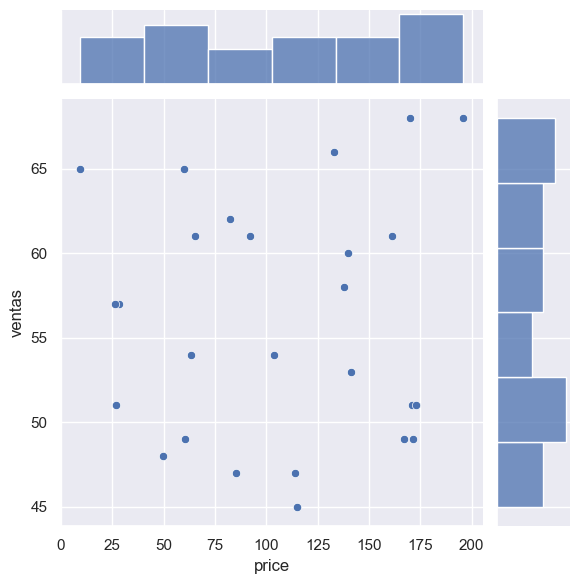

In [ ]:
# Contamos cuántas veces se ha vendido cada producto
ventas_por_producto = df_productos_vendidos.merge(df_productos[['id', 'product_name', 'price']], 
                                                   left_on='product_id', 
                                                   right_on='id')

# Jointplot entre precio y número de ventas
ventas_contadas = ventas_por_producto.groupby(['product_name', 'price']).size().reset_index(name='ventas')

sns.jointplot(data=ventas_contadas, x='price', y='ventas')
plt.show()

Relación entre precio y número de ventas:
el jointplot combina un scatter plot central con histogramas en los bordes. Los histogramas muestran que los precios se distribuyen de forma bastante uniforme entre 0 y 200, y que la mayoría de los productos tienen entre 45 y 68 ventas. Los puntos del scatter plot están dispersos sin ningún patrón claro,lo que indica que el precio de un producto no determina cuántas veces se vende.

## NIVEL 3: Power BI con Python

In [ ]:
# Añadimos id único a la tabla sold_products para evitar que Power BI elimine duplicados
df_productos_vendidos['id'] = range(len(df_productos_vendidos))

# Conectamos Python a Power BI para que se puedan visualizar los datos.